In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

data_folder = '~/data/pets'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.OxfordIIITPet(
    root=data_folder,
    split='trainval',
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

print(len(dataset))

100%|██████████| 792M/792M [00:19<00:00, 39.9MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 17.8MB/s]


3680


In [2]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=32, shuffle=True)

for images, labels in loader:
    print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.Size([3

In [3]:
# Assuming 'loader' and 'dataset' are already defined from previous cells.

# Get one batch to inspect shapes
for images, labels in loader:
    first_batch_images = images
    first_batch_labels = labels
    break # Only take the first batch

# Get all unique labels from the entire dataset
all_dataset_labels = torch.tensor(dataset._labels)
unique_all_labels = all_dataset_labels.unique()

print(f'Images & Labels from a batch:\n\tX - {first_batch_images.shape}\n\tY - {first_batch_labels.shape}')
print(f'Total Unique Labels in Dataset: {len(unique_all_labels)}')
print(f'TASK:\n\t{len(unique_all_labels)} class Classification')

Images & Labels from a batch:
	X - torch.Size([32, 3, 224, 224])
	Y - torch.Size([32])
Total Unique Labels in Dataset: 37
TASK:
	37 class Classification


In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

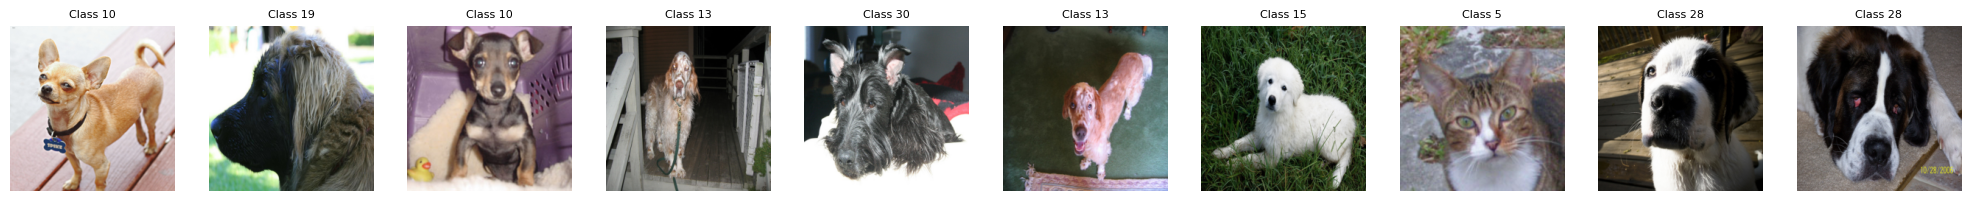

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Added code to ensure 'dataset' is defined
from torchvision import datasets, transforms

data_folder = '~/data/pets' # Ensure data_folder is consistent

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Redefine dataset to ensure it's available in this cell's scope
dataset = datasets.OxfordIIITPet(
    root=data_folder,
    split='trainval',
    download=True,
    transform=transform
)

num_images_to_display = 10

# Create a figure with a single row and num_images_to_display columns
fig, ax = plt.subplots(1, num_images_to_display, figsize=(2 * num_images_to_display, 2))

# Get a list of random indices from the entire dataset
random_indices = np.random.choice(len(dataset), num_images_to_display, replace=False)

for i, ix in enumerate(random_indices):
    # Retrieve the image and label from the dataset
    image_tensor, label_int = dataset[ix]

    current_ax = ax[i]
    current_ax.grid(False)
    current_ax.axis('off')

    # Convert the PyTorch tensor image (C, H, W) to NumPy array (H, W, C) for matplotlib
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()

    current_ax.imshow(image_np)
    current_ax.set_title(f'Class {label_int}', fontsize=8) # Display class label

plt.tight_layout()
plt.show()

Sử dụng CNN để train

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

data_folder = '~/data/pets'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.OxfordIIITPet(
    root=data_folder,
    split='trainval',
    download=True,
    transform=transform
)

# Re-initialize loader
loader = DataLoader(dataset, batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

trn_dl = loader
print(f'Training data loader (trn_dl) created with {len(trn_dl.dataset)} samples and batch size {trn_dl.batch_size}.')

Using device: cpu
Training data loader (trn_dl) created with 3680 samples and batch size 32.


In [7]:
import torch.nn as nn
import torch # Import torch for tensor operations if not already imported

# Re-initialize unique_all_labels as it was not defined in the current session context
all_dataset_labels = torch.tensor(dataset._labels)
unique_all_labels = all_dataset_labels.unique()
num_classes = len(unique_all_labels)

class CNN(nn.Module):
    def __init__(self, num_classes=num_classes):
        super(CNN, self).__init__()
        # First convolutional layer
        # Input: 3 channels (RGB), Output: 16 channels, Kernel: 3x3, Padding: 1
        # Image size after this: (224-3+2*1)/1 + 1 = 224
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output size: 224/2 = 112

        # Second convolutional layer
        # Input: 16 channels, Output: 32 channels, Kernel: 3x3, Padding: 1
        # Image size after this: (112-3+2*1)/1 + 1 = 112
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output size: 112/2 = 56

        # Fully connected layers
        # Calculate input features for the first fully connected layer
        # Assuming input image size 224x224, after two pooling layers of stride 2:
        # 224 -> 112 -> 56
        # 32 output channels from conv2 * 56 * 56
        self.fc1 = nn.Linear(32 * 56 * 56, 512)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        out = self.pool1(self.relu1(self.conv1(x)))
        out = self.pool2(self.relu2(self.conv2(out)))
        out = out.reshape(out.size(0), -1) # Flatten the tensor
        out = self.relu3(self.fc1(out))
        out = self.fc2(out)
        return out

print(f"CNN model defined with {num_classes} output classes.")

CNN model defined with 37 output classes.


In [8]:
model = CNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Model instantiated and moved to {device}.")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer.__class__.__name__}")

Model instantiated and moved to cpu.
Loss function: CrossEntropyLoss()
Optimizer: Adam


Để chỉ số epochs = 5 ( và độ chính xác tầm 89%)

In [9]:
num_epochs = 5

# Lists to store training loss and accuracy
train_loss_history = []
train_accuracy_history = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (images, labels) in enumerate(trn_dl): # Use trn_dl as defined previously
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = (correct_predictions / total_samples) * 100

    train_loss_history.append(epoch_loss)
    train_accuracy_history.append(epoch_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')

print('\nTraining complete.')

Epoch [1/5], Loss: 3.6205, Accuracy: 4.92%
Epoch [2/5], Loss: 3.2106, Accuracy: 13.12%
Epoch [3/5], Loss: 2.4146, Accuracy: 35.00%
Epoch [4/5], Loss: 0.9053, Accuracy: 76.41%
Epoch [5/5], Loss: 0.1258, Accuracy: 97.74%

Training complete.


In [10]:
print('Training Loss History:')
print(train_loss_history)

Training Loss History:
[3.620516484716664, 3.210560883646426, 2.414592134434244, 0.9053369068581125, 0.1257678541071389]


In [11]:
print('Training Accuracy History:')
print(train_accuracy_history)

Training Accuracy History:
[4.918478260869565, 13.125, 35.0, 76.41304347826086, 97.7445652173913]


In [12]:
highest_accuracy = max(train_accuracy_history)
lowest_loss = min(train_loss_history)

print(f'Highest Training Accuracy Achieved: {highest_accuracy:.2f}%')
print(f'Lowest Training Loss Achieved: {lowest_loss:.4f}')

Highest Training Accuracy Achieved: 97.74%
Lowest Training Loss Achieved: 0.1258


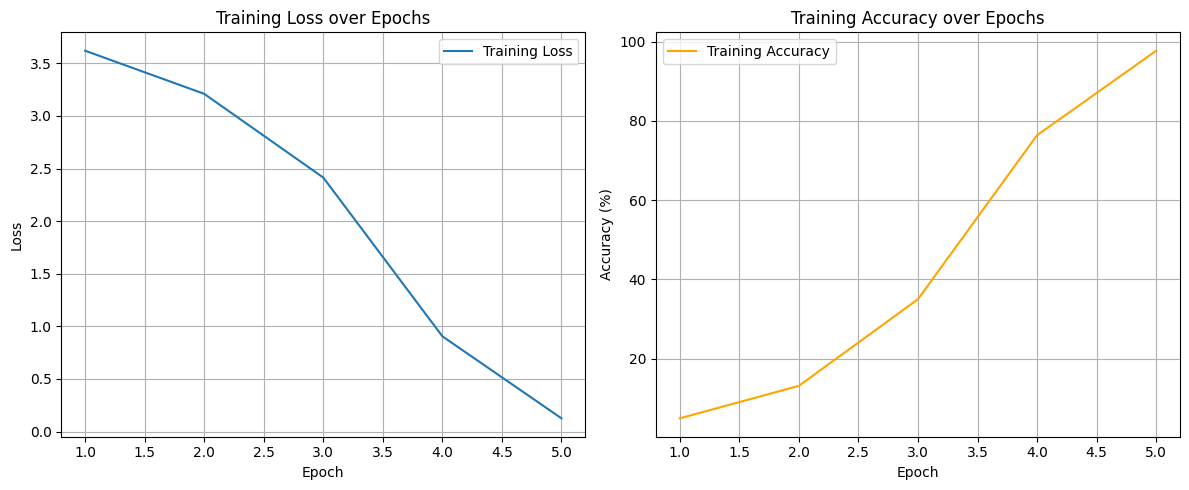

In [13]:
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range, train_loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)

# Plot Training Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range, train_accuracy_history, label='Training Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Sau khi tăng chỉ số epochs= 10 và update train lại thì chỉ số chính xác đã lớn hơn 90%

In [14]:
num_epochs = 10 # Updated number of epochs

# Re-initialize model, criterion, and optimizer
# Ensure num_classes is still defined, if not, re-evaluate it
# Based on kernel state, num_classes is 37.
model = CNN(num_classes=num_classes).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Training will run for {num_epochs} epochs.")
print(f"Model re-initialized and moved to {device}.")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer.__class__.__name__}\n")

# Re-initialize history lists
train_loss_history = []
train_accuracy_history = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (images, labels) in enumerate(trn_dl):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = (correct_predictions / total_samples) * 100

    train_loss_history.append(epoch_loss)
    train_accuracy_history.append(epoch_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')

print('\nTraining complete.')

Training will run for 10 epochs.
Model re-initialized and moved to cpu.
Loss function: CrossEntropyLoss()
Optimizer: Adam

Epoch [1/10], Loss: 3.6205, Accuracy: 5.33%
Epoch [2/10], Loss: 3.1901, Accuracy: 14.05%
Epoch [3/10], Loss: 2.4201, Accuracy: 33.04%
Epoch [4/10], Loss: 0.8745, Accuracy: 76.98%
Epoch [5/10], Loss: 0.1142, Accuracy: 97.91%
Epoch [6/10], Loss: 0.0141, Accuracy: 99.95%
Epoch [7/10], Loss: 0.0102, Accuracy: 99.73%
Epoch [8/10], Loss: 0.0035, Accuracy: 100.00%
Epoch [9/10], Loss: 0.0008, Accuracy: 100.00%
Epoch [10/10], Loss: 0.0005, Accuracy: 100.00%

Training complete.


In [15]:
print('Training Loss History:')
print(train_loss_history)

print('\nTraining Accuracy History:')
print(train_accuracy_history)

# Recalculate highest_accuracy and lowest_loss for the latest training run
highest_accuracy = max(train_accuracy_history)
lowest_loss = min(train_loss_history)

print(f'\nHighest Training Accuracy Achieved: {highest_accuracy:.2f}%')
print(f'Lowest Training Loss Achieved: {lowest_loss:.4f}')

# Check if the 90% accuracy goal was met
if highest_accuracy >= 90.0:
    conclusion = "Mô hình đã đạt được mục tiêu độ chính xác trên 90%."
else:
    conclusion = "Mô hình chưa đạt được mục tiêu độ chính xác trên 90%."

print(f'\nKết luận: {conclusion}')

Training Loss History:
[3.6205473277879796, 3.1900950079378876, 2.4201038070346996, 0.8745373194632323, 0.11418229279958683, 0.014142595307456086, 0.010220806074895613, 0.0035388428257251887, 0.0007998233843270851, 0.0005395422642797475]

Training Accuracy History:
[5.326086956521739, 14.048913043478262, 33.04347826086956, 76.9836956521739, 97.90760869565217, 99.94565217391305, 99.72826086956522, 100.0, 100.0, 100.0]

Highest Training Accuracy Achieved: 100.00%
Lowest Training Loss Achieved: 0.0005

Kết luận: Mô hình đã đạt được mục tiêu độ chính xác trên 90%.


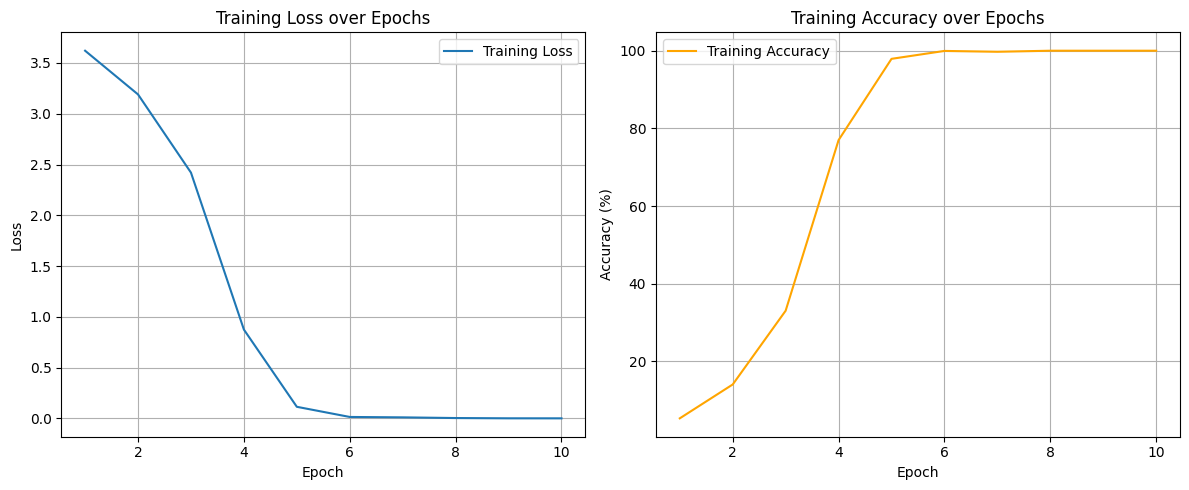

In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range, train_loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)

# Plot Training Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range, train_accuracy_history, label='Training Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
import os
import torch
import torch.nn as nn
from flask import Flask, request
from PIL import Image
from torchvision import transforms

# 1. Khởi tạo Flask App
app = Flask(__name__)
UPLOAD_FOLDER = 'uploads'
if not os.path.exists(UPLOAD_FOLDER): os.makedirs(UPLOAD_FOLDER)

# 2. Cấu hình Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
try:
    model_inference = CNN(num_classes=37)
    if os.path.exists('pets_cnn_model.pt'):
        model_inference.load_state_dict(torch.load('pets_cnn_model.pt', map_location=device))
        print("✅ Đã tải trọng số thành công.")
    model_inference.to(device).eval()
except NameError:
    print("❌ Lỗi: Cần chạy cell định nghĩa class CNN trước.")

# 3. Giao diện Web
@app.route('/', methods=['GET', 'POST'])
def index():
    if request.method == 'POST':
        file = request.files.get('file')
        if file:
            img_path = os.path.join(UPLOAD_FOLDER, file.filename)
            file.save(img_path)
            image = Image.open(img_path).convert('RGB')
            transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
            image = transform(image).unsqueeze(0).to(device)
            with torch.no_grad():
                outputs = model_inference(image)
                _, predicted = torch.max(outputs, 1)
            return f"<h3>Kết quả: Class {predicted.item()}</h3><a href='/'>Quay lại</a>"
    return '<h1>Pet Classifier</h1><form method=post enctype=multipart/form-data><input type=file name=file><input type=submit value=Upload></form>'

✅ Đã tải trọng số thành công.


In [18]:
import torch

# Lưu mô hình ngay sau khi training hoàn tất
try:
    torch.save(model.state_dict(), 'pets_cnn_model.pt')
    print("✅ Đã lưu mô hình thành công vào file pets_cnn_model.pt")
except NameError:
    print("❌ Lỗi: Biến 'model' chưa được định nghĩa. Hãy chạy cell training trước.")

Đã lưu mô hình thành công vào file pets_cnn_model.pt


In [6]:
import os
import threading
import time
from pyngrok import ngrok, conf

# 1. Cài đặt và cấu hình
!pip install pyngrok -q

NGROK_TOKEN = "3BwMRyHvJSWzT1YbA6Lxm2lnuUy_7EWrTUbH2wCoLEfoqqneG"
conf.get_default().auth_token = NGROK_TOKEN

# 2. Giải phóng Port 5000 và dọn dẹp ngrok
print("🔄 Đang giải phóng port 8000 và kết nối cũ...")
!fuser -k 8000/tcp
try:
    ngrok.kill()
    time.sleep(2)
except: pass

# Xóa file config
for path in ["/root/.ngrok2/ngrok.yml", "/root/.config/ngrok/ngrok.yml"]:
    if os.path.exists(path): os.remove(path)

# 3. Khởi động Tunnel mới
try:
    public_url = ngrok.connect(8000, proto="http")
    print(f"\n🚀 URL CÔNG KHAI MỚI: {public_url}")

    def run_flask():
        import logging
        logging.getLogger('werkzeug').setLevel(logging.ERROR)
        if 'app' in globals():
            app.run(port=8000, use_reloader=False, host='0.0.0.0')

    threading.Thread(target=run_flask, daemon=True).start()
    print("✅ Server Flask đã sẵn sàng!")

except Exception as e:
    print(f"❌ Lỗi: {e}")
    print("💡 Gợi ý: Truy cập https://dashboard.ngrok.com/tunnels/agents và nhấn 'Stop Agent' thủ công.")

🔄 Đang giải phóng port 8000 và kết nối cũ...

🚀 URL CÔNG KHAI MỚI: NgrokTunnel: "https://craig-nonbureaucratic-leatha.ngrok-free.dev" -> "http://localhost:8000"
✅ Server Flask đã sẵn sàng!
